In [2]:
# All necessary libraries

import MDAnalysis as mda
import os
import MDAnalysis.transformations as trans
import numpy as np
import pandas as pd
import parmed as pmd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

In [3]:
# Any polyprotic acid sate can be presented in a binary format
# containing 0 and 1 where 0 denotes deprotonated state and 1 - protonated
biliverdin_species = ["S11111", 
                      "S11011",
                      "S10111",
                      "S10011",
                      "S10001",
                      "S00001",
                      "S10000",
                      "S00000"
]

# set up temperatures for parallel tempering 
# efficient transition happens when temperature window is small enough
# wandow size was estimated using this web site: https://virtualchemistry.org/remd-temperature-generator/
temperatures = [str(t) for t in list(range(300, 404, 4))]


In [16]:
# define helper functions

def wb97xd_error(energy):
    """ Systematic correction of the calculated energy"""
    return 0.346 + 0.72 * energy 
    
def name2charge(name):
    """ Charge from the name """
    return name.count("1") - 4

def numatoms(name):
    """ Number of atoms from the name """
    return name.count("1") + 72


def surrounding_indices(idx):
    """
    This function openes a pdb file with coordinates
    """
    with open(f'selected_{idx}.pdb', 'r') as f:
        data = f.readlines()
    resids = set([int(line[22:26]) for line in data if line.startswith('ATOM')])
    resids.discard(1)

    indices = []
    charge = 0
    
    with open(f'system_{idx}.pdb', 'r') as f:
        data = f.readlines()
        
    for line in data:
        if line.startswith('ATOM'):
            if int(line[22:26]) in resids:
                indices.append(int(line[7:11]) - 1)
                if line[17:20] == 'Cl-':
                    charge -= 1
                elif line[17:20] == 'Na+':
                    charge += 1
                
    indices = [str(i) for i in indices]
    return indices, charge

def read_wavelengths_and_fosc(filename):
    """ 
    Extraction of transition energies from ORCA outputfile
    """
    
    with open(filename, 'r') as f:
        data = f.readlines() 
    
    # get index of the line of interest
    for line in data:
        if 'ABSORPTION SPECTRUM VIA TRANSITION ELECTRIC DIPOLE MOMENTS' in line:
            idx = data.index(line)
            
            line1 = list(filter(None, data[idx+5].split()))
            line2 = list(filter(None, data[idx+6].split()))
            line3 = list(filter(None, data[idx+7].split()))
            line4 = list(filter(None, data[idx+8].split()))
            line5 = list(filter(None, data[idx+9].split()))
            line6 = list(filter(None, data[idx+10].split()))
            line7 = list(filter(None, data[idx+11].split()))
            line8 = list(filter(None, data[idx+12].split()))
            line9 = list(filter(None, data[idx+13].split()))
            line10 = list(filter(None, data[idx+14].split()))

            w1, f1 = line1[2], line1[3]
            w2, f2 = line2[2], line2[3]
            w3, f3 = line3[2], line3[3]
            w4, f4 = line4[2], line4[3]
            w5, f5 = line5[2], line5[3]
            w6, f6 = line6[2], line6[3]
            w7, f7 = line7[2], line7[3]
            w8, f8 = line8[2], line8[3]
            w9, f9 = line9[2], line9[3]
            w10, f10 = line10[2], line10[3]

            return [w1, w2, w3, w4, w5, w6, w7, w8, w9, w10, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10]
    raise Exception("Absorption data Not Found")


def nm2ev(wv):
    return 1239.8 / wv


def ev2nm(wavelength):
    return 1239.81 / wavelength


def rewrite_xyz(filename):
    """
    MDAnalysis produces XYZ files with element symbols containing digits or '+' and '-' for ions
    This function removes digits and other characters
    """
    with open(filename, 'r') as f:
        data = f.readlines()
    for i in range(2, len(data)-1):
        line = data[i].split()
        line = list(filter(None, line))
        
        if len(line) != 0:
            line[0] = ''.join([i for i in line[0] if not (i.isdigit() or i == '-' or i == '+')])
        line = ' '.join(line)
        data[i] = line + '\n'
    with open(filename, 'w') as f:
        f.write(''.join(data))


def generate_spectra_from_single_excitations(spectral_data, 
                                             s,
                                             num_spec_points = 500,
                                             concentration = 1e-4):
    """
    Takes a dictionary with excitation and places gaussians with predefined sigmas
    and returns a numpy array
    """

    
    visible_ev = np.linspace(1.63, 3.26, num_spec_points)
    visible_ev = np.array(visible_ev).reshape(-1, 1)
    
    spectral_data['w1'] = np.repeat(spectral_data['w1'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w2'] = np.repeat(spectral_data['w2'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w3'] = np.repeat(spectral_data['w3'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w4'] = np.repeat(spectral_data['w4'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w5'] = np.repeat(spectral_data['w5'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w6'] = np.repeat(spectral_data['w6'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w7'] = np.repeat(spectral_data['w7'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w8'] = np.repeat(spectral_data['w8'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w9'] = np.repeat(spectral_data['w9'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['w10'] = np.repeat(spectral_data['w10'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f1'] = np.repeat(spectral_data['f1'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f2'] = np.repeat(spectral_data['f2'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f3'] = np.repeat(spectral_data['f3'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f4'] = np.repeat(spectral_data['f4'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f5'] = np.repeat(spectral_data['f5'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f6'] = np.repeat(spectral_data['f6'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f7'] = np.repeat(spectral_data['f7'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f8'] = np.repeat(spectral_data['f8'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f9'] = np.repeat(spectral_data['f9'].reshape(1, -1), repeats = num_spec_points, axis=0)
    spectral_data['f10'] = np.repeat(spectral_data['f10'].reshape(1, -1), repeats = num_spec_points, axis=0)

    w1_exp = np.sum(spectral_data['f1'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w1'])**2 / s**2), axis=1)
    w2_exp = np.sum(spectral_data['f2'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w2'])**2 / s**2), axis=1)
    w3_exp = np.sum(spectral_data['f3'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w3'])**2 / s**2), axis=1)
    w4_exp = np.sum(spectral_data['f4'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w4'])**2 / s**2), axis=1)
    w5_exp = np.sum(spectral_data['f5'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w5'])**2 / s**2), axis=1)
    w6_exp = np.sum(spectral_data['f6'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w6'])**2 / s**2), axis=1)
    w7_exp = np.sum(spectral_data['f7'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w7'])**2 / s**2), axis=1)
    w8_exp = np.sum(spectral_data['f8'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w8'])**2 / s**2), axis=1)
    w9_exp = np.sum(spectral_data['f8'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w9'])**2 / s**2), axis=1)
    w10_exp = np.sum(spectral_data['f10'] * np.exp(-4 * np.log(2) * (visible_ev - spectral_data['w10'])**2 / s**2), axis=1)

    # multiplicatio by normalisation coefficients and addition of lines
    sp = 1 / s * np.sqrt(4 * np.log(2)/np.pi) * w1_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w2_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w3_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w4_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w5_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w6_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w7_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w8_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w9_exp + \
         1 / s * np.sqrt(4 * np.log(2)/np.pi) * w10_exp
    

    sp /= num_spectra_read

    # convert to f_osc spectrum to optical density 
    sp = 11451.73 * concentration * sp

    return sp

class Spectrum:

    """A class to represent VIS absorption spectrum and convert it to xyz and rgb"""
    

    # The CIE colour matching function for 380 - 780 nm in 5 nm intervals
    cmf = np.array([[1.4000e-03, 0.0000e+00, 6.5000e-03], [2.2000e-03, 1.0000e-04, 1.0500e-02],
                    [4.2000e-03, 1.0000e-04, 2.0100e-02], [7.6000e-03, 2.0000e-04, 3.6200e-02],
                    [1.4300e-02, 4.0000e-04, 6.7900e-02], [2.3200e-02, 6.0000e-04, 1.1020e-01],
                    [4.3500e-02, 1.2000e-03, 2.0740e-01], [7.7600e-02, 2.2000e-03, 3.7130e-01],
                    [1.3440e-01, 4.0000e-03, 6.4560e-01], [2.1480e-01, 7.3000e-03, 1.0391e+00],
                    [2.8390e-01, 1.1600e-02, 1.3856e+00], [3.2850e-01, 1.6800e-02, 1.6230e+00],
                    [3.4830e-01, 2.3000e-02, 1.7471e+00], [3.4810e-01, 2.9800e-02, 1.7826e+00],
                    [3.3620e-01, 3.8000e-02, 1.7721e+00], [3.1870e-01, 4.8000e-02, 1.7441e+00],
                    [2.9080e-01, 6.0000e-02, 1.6692e+00], [2.5110e-01, 7.3900e-02, 1.5281e+00],
                    [1.9540e-01, 9.1000e-02, 1.2876e+00], [1.4210e-01, 1.1260e-01, 1.0419e+00],
                    [9.5600e-02, 1.3900e-01, 8.1300e-01], [5.8000e-02, 1.6930e-01, 6.1620e-01],
                    [3.2000e-02, 2.0800e-01, 4.6520e-01], [1.4700e-02, 2.5860e-01, 3.5330e-01],
                    [4.9000e-03, 3.2300e-01, 2.7200e-01], [2.4000e-03, 4.0730e-01, 2.1230e-01],
                    [9.3000e-03, 5.0300e-01, 1.5820e-01], [2.9100e-02, 6.0820e-01, 1.1170e-01],
                    [6.3300e-02, 7.1000e-01, 7.8200e-02], [1.0960e-01, 7.9320e-01, 5.7300e-02],
                    [1.6550e-01, 8.6200e-01, 4.2200e-02], [2.2570e-01, 9.1490e-01, 2.9800e-02],
                    [2.9040e-01, 9.5400e-01, 2.0300e-02], [3.5970e-01, 9.8030e-01, 1.3400e-02],
                    [4.3340e-01, 9.9500e-01, 8.7000e-03], [5.1210e-01, 1.0000e+00, 5.7000e-03],
                    [5.9450e-01, 9.9500e-01, 3.9000e-03], [6.7840e-01, 9.7860e-01, 2.7000e-03],
                    [7.6210e-01, 9.5200e-01, 2.1000e-03], [8.4250e-01, 9.1540e-01, 1.8000e-03],
                    [9.1630e-01, 8.7000e-01, 1.7000e-03], [9.7860e-01, 8.1630e-01, 1.4000e-03],
                    [1.0263e+00, 7.5700e-01, 1.1000e-03], [1.0567e+00, 6.9490e-01, 1.0000e-03],
                    [1.0622e+00, 6.3100e-01, 8.0000e-04], [1.0456e+00, 5.6680e-01, 6.0000e-04],
                    [1.0026e+00, 5.0300e-01, 3.0000e-04], [9.3840e-01, 4.4120e-01, 2.0000e-04],
                    [8.5440e-01, 3.8100e-01, 2.0000e-04], [7.5140e-01, 3.2100e-01, 1.0000e-04],
                    [6.4240e-01, 2.6500e-01, 0.0000e+00], [5.4190e-01, 2.1700e-01, 0.0000e+00],
                    [4.4790e-01, 1.7500e-01, 0.0000e+00], [3.6080e-01, 1.3820e-01, 0.0000e+00],
                    [2.8350e-01, 1.0700e-01, 0.0000e+00], [2.1870e-01, 8.1600e-02, 0.0000e+00],
                    [1.6490e-01, 6.1000e-02, 0.0000e+00], [1.2120e-01, 4.4600e-02, 0.0000e+00],
                    [8.7400e-02, 3.2000e-02, 0.0000e+00], [6.3600e-02, 2.3200e-02, 0.0000e+00],
                    [4.6800e-02, 1.7000e-02, 0.0000e+00], [3.2900e-02, 1.1900e-02, 0.0000e+00],
                    [2.2700e-02, 8.2000e-03, 0.0000e+00], [1.5800e-02, 5.7000e-03, 0.0000e+00],
                    [1.1400e-02, 4.1000e-03, 0.0000e+00], [8.1000e-03, 2.9000e-03, 0.0000e+00],
                    [5.8000e-03, 2.1000e-03, 0.0000e+00], [4.1000e-03, 1.5000e-03, 0.0000e+00],
                    [2.9000e-03, 1.0000e-03, 0.0000e+00], [2.0000e-03, 7.0000e-04, 0.0000e+00],
                    [1.4000e-03, 5.0000e-04, 0.0000e+00], [1.0000e-03, 4.0000e-04, 0.0000e+00],
                    [7.0000e-04, 2.0000e-04, 0.0000e+00], [5.0000e-04, 2.0000e-04, 0.0000e+00],
                    [3.0000e-04, 1.0000e-04, 0.0000e+00], [2.0000e-04, 1.0000e-04, 0.0000e+00],
                    [2.0000e-04, 1.0000e-04, 0.0000e+00], [1.0000e-04, 0.0000e+00, 0.0000e+00],
                    [1.0000e-04, 0.0000e+00, 0.0000e+00], [1.0000e-04, 0.0000e+00, 0.0000e+00],
                    [0.0000e+00, 0.0000e+00, 0.0000e+00]])
    
    # The CIE D65 light source intensity for 380 - 780 nm in 5 nm intervals
    d65 = np.array([ 49.9755,  52.3118,  54.6482,  68.7015,  82.7549,  87.1204,
                     91.486 ,  92.4589,  93.4318,  90.057 ,  86.6823,  95.7736,
                    104.865 , 110.936 , 117.008 , 117.41  , 117.812 , 116.336 ,
                    114.861 , 115.392 , 115.923 , 112.367 , 108.811 , 109.082 ,
                    109.354 , 108.578 , 107.802 , 106.296 , 104.79  , 106.239 ,
                    107.689 , 106.047 , 104.405 , 104.225 , 104.046 , 102.023 ,
                    100.    ,  98.1671,  96.3342,  96.0611,  95.788 ,  92.2368,
                     88.6856,  89.3459,  90.0062,  89.8026,  89.5991,  88.6489,
                     87.6987,  85.4936,  83.2886,  83.4939,  83.6992,  81.863 ,
                     80.0268,  80.1207,  80.2146,  81.2462,  82.2778,  80.281 ,
                     78.2842,  74.0027,  69.7213,  70.6652,  71.6091,  72.979 ,
                     74.349 ,  67.9765,  61.604 ,  65.7448,  69.8856,  72.4863,
                     75.087 ,  69.3398,  63.5927,  55.0054,  46.4182,  56.6118,
                     66.8054,  65.0941,  63.3828])
    
    # Adobe RGB (1998): D65
    xyz2rgb = np.array([[ 2.0413690, -0.5649464, -0.3446944],
                        [-0.9692660,  1.8760108,  0.0415560],
                        [ 0.0134474, -0.1183897,  1.0154096]])
                        
    rgb2xyz = np.array([[0.5767309,  0.1855540,  0.1881852],
                        [0.2973769,  0.6273491,  0.0752741],
                        [0.0270343,  0.0706872,  0.9911085]])
                        
                        
    def __init__(self, spectrum_range, spectrum_intensities, absorbance = True):
        
        self.spectrum_intensities = spectrum_intensities
        self.spectrum_range = spectrum_range
       
        #make sure spectra are sorted before the interpolation
        self.spectrum_range, self.spectrum_intensities = zip(*sorted(zip(self.spectrum_range, self.spectrum_intensities)))
        
        try:
           self.spectrum_intensities = np.array(self.spectrum_intensities).astype(float)
           self.spectrum_range = np.array(self.spectrum_range).astype(float)
        except:
           raise TypeError("Spectrum intensities or spectrum range cannot be converted into numpy arrays")
        
        # change potential negative values to 0
        self.spectrum_intensities[self.spectrum_intensities < 0] = 0.

        if absorbance:
            self.spectrum_intensities = 1 - 10**(-self.spectrum_intensities)

        # convert spectrum to range 380-780 nm with 5 nm step
        self.interp_spectrum = np.interp(np.linspace(380, 780, 81),
                                         self.spectrum_range,
                                         self.spectrum_intensities)
                                         
        #scale spectrum between 0 and 1 currently but do not do not check whether we recorded transmission or absorbance
        self.spectrum_intensities = self.spectrum_intensities / np.max(self.spectrum_intensities)
        

    def generate_XYZ(self):
        reflectance = (1 - self.interp_spectrum) * self.d65 # only reflected/transmitted light is perceived
        XYZ = np.sum(reflectance.reshape(81, 1) *           # reshape spectrum to make three channels
                     np.ones((81, 3)) *                     # shape is predefined 380 -> 780 with 5 nm step makes hardcodes number of spectrum values
                     Spectrum.cmf,                          # colour matching function for red, green, and blue 
                     axis = 0)
        
        if sum(XYZ) == 0.:
           return XYZ
           
        return XYZ / sum(XYZ)
        
        
    def generate_RGB(self):
        XYZ = self.generate_XYZ()
        rgb = self.xyz2rgb @ XYZ[:, np.newaxis]
        
        if np.any(rgb < 0):
            # We're not in the RGB gamut: approximate by desaturating
            w = - np.min(rgb)
            rgb += w
        if not np.all(rgb==0):
            # Normalize the rgb vector
            rgb /= np.max(rgb)
            
        return rgb.reshape(3)
        
    def rgb_to_hex(self):
        """Convert from fractional rgb values to HTML-style hex string."""
        
        hex_rgb = (255 * self.generate_RGB()).astype(int)
        return '#{:02x}{:02x}{:02x}'.format(*hex_rgb)


- This step requires trajectories from REMD simulations present in the corresponding directories
- At this point when the trajectory is generated the trajectory is centered on the colourant structure and it is necessary to make sure that no molecules are broken by periodic boundary conditions
- MDAnalysis is used to selet water and ions and and use their indices to specify the subsystem to be treated with GFN2-xTB model
- Then xyz coordinates of frames are written to use in QM calculations

In [ ]:
for spec in biliverdin_species:
    
    os.chdir(f"{spec}")

    # wrapping solvent around molecule and save in traj.xtc file at 300 K
    os.system("echo 2 0 | gmx_mpi trjconv -s 300/prod.tpr -f 300/traj_comp.xtc -o 300/traj.xtc -center -pbc mol -ur compact")

    # opening and the converted trajectory and selection of residues around the colourant
    u = mda.Universe(f'{spec}.gro', '300/traj.xtc')
    around = u.select_atoms('(byres around 5.0 resid 1) or resid 1', updating=True, periodic=False)

    
    cnt = 1
    for ts in u.trajectory:
        with mda.Writer(f"selected_{cnt}.xyz", multiframe=False) as w:
            w.write(around)
        with mda.Writer(f"system_{cnt}.xyz", multiframe=False) as w:
            w.write(u)
        with mda.Writer(f"selected_{cnt}.pdb", multiframe=False) as w:
            w.write(around)
        with mda.Writer(f"system_{cnt}.pdb", multiframe=False) as w:
            w.write(u)
        
        # xyz file contains numbers with atomic symbols and we have to remove them before we can manipulate
        rewrite_xyz(f"selected_{cnt}.xyz")
        rewrite_xyz(f"system_{cnt}.xyz")
        
        cnt += 1

    os.chdir("..")

- The next step includes:
  * extraction of conformations
  * creation directories for calculation
  * ORCA input file generation 

In [ ]:
num = 5001 # number of conformations extracted

for spec in biliverdin_species:
    
    os.chdir(f"{spec}")
    
    # create topology for QM-MM
    os.system(f'orca_mm -convff -AMBER {spec}.prmtop')
    
    for idx in range(1, 5001):
        if not os.path.isdir(f'tddft_{idx+1}'):
            os.mkdir(f'tddft_{idx+1}')
            
        os.system(f'cp system_{idx+1}.pdb tddft_{idx+1}')
        
        biliverdin_charge = name2charge(spec)
        biliverdin_atoms = numatoms(spec)
        surroundings, surrounding_charge = surrounding_indices(idx + 1)
        
        inp  = "!QM/XTB/MM wB97X-D4 ma-def2-SVP RIJCOSX def2/J PAL16 TightSCF\n"
        inp += "%maxcore 4000\n"
        inp += "%scf MaxIter 1500 end\n"
        inp += f'%base "{spec}_{idx+1}"\n'
        inp += '%tddft nroots 10 tda False end\n'
        inp += '%qmmm\n'
        inp += f' ORCAFFFilename "../{spec}.ORCAFF.prms"\n'
        inp += ' QMAtoms {0:' + str(biliverdin_atoms) + '} end\n'
        inp += ' QM2Atoms {' + ' '.join(surroundings) + '} end\n'
        inp += f' Charge_Medium {surrounding_charge} end\n\n'
        inp += f'*pdbfile {biliverdin_charge} 1 system_{idx+1}.pdb\n'

        with open(f'./tddft_{idx+1}/calc.inp', 'w') as f:
            f.write(inp)
    
    os.chdir("..")


The nex step is to extract electron excitation energies from ORCA output file, generate absorption spectra and corresponding colours

S11111


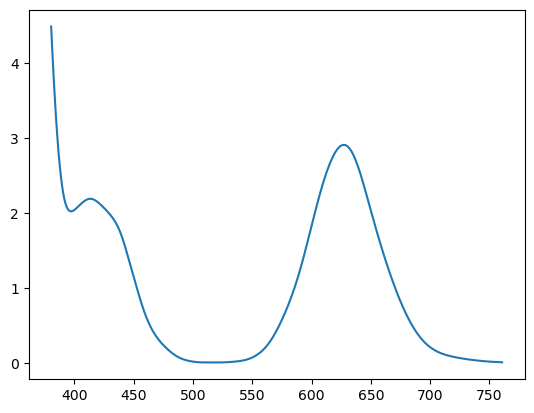

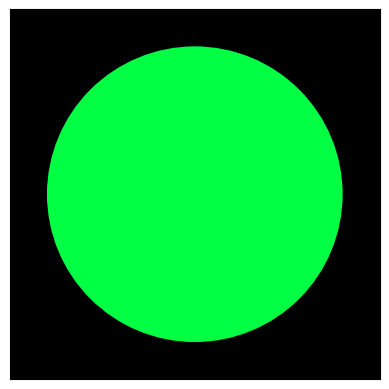

S11011


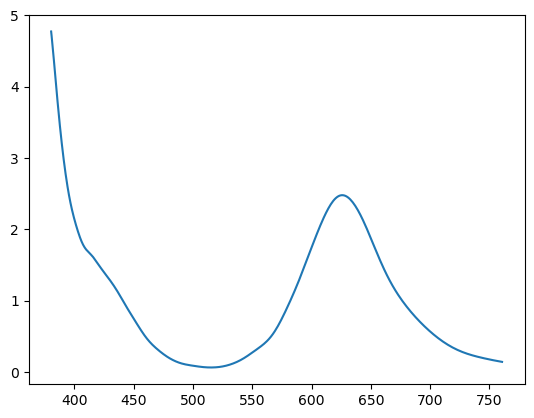

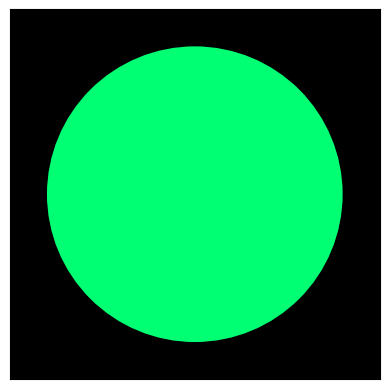

S10111


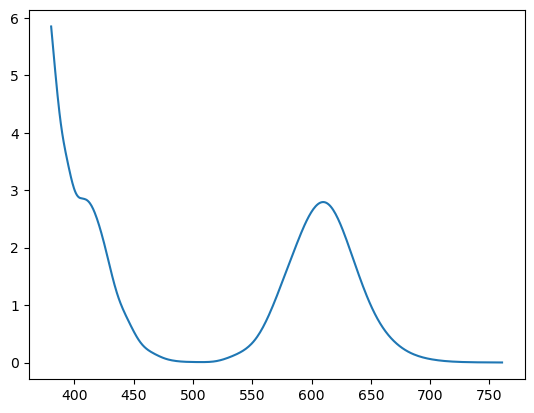

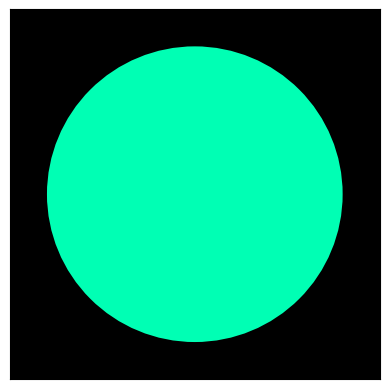

S10011


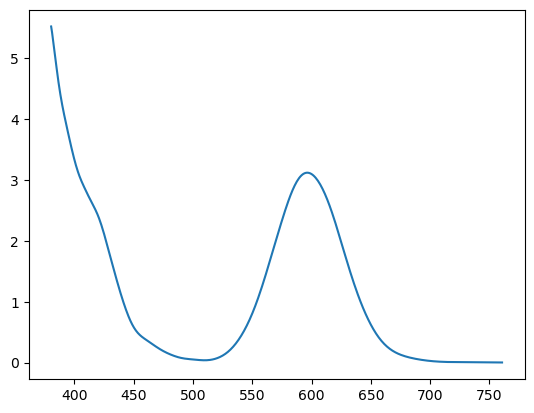

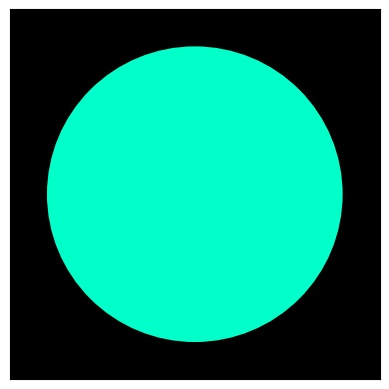

S10001


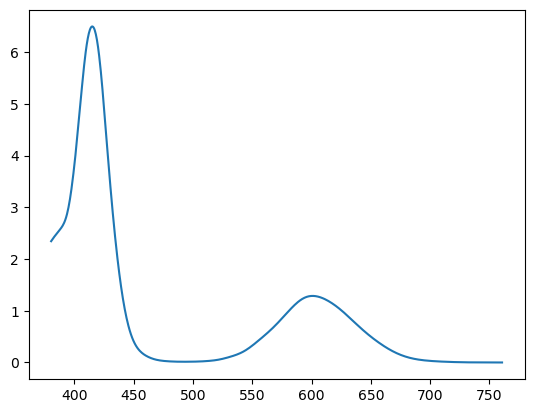

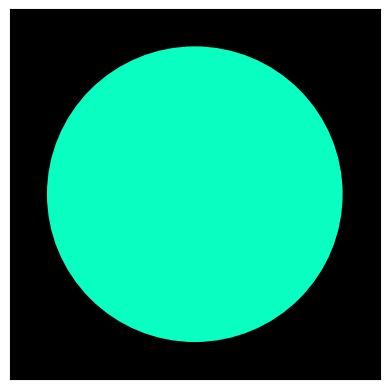

S00001


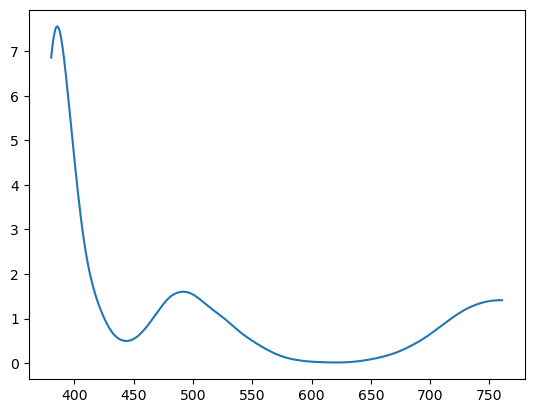

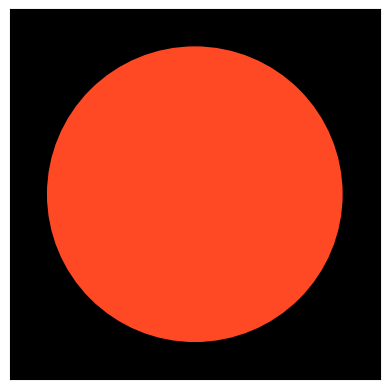

S10000


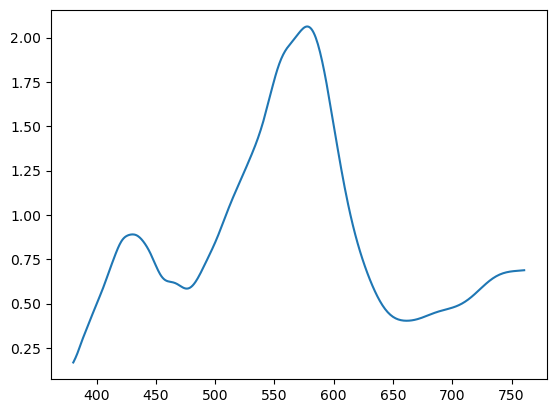

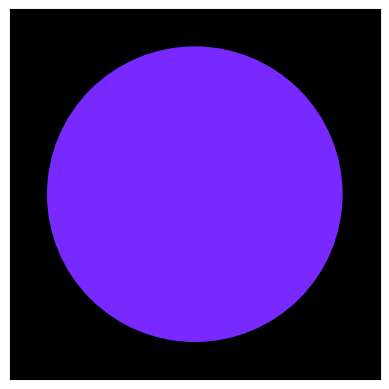

S00000


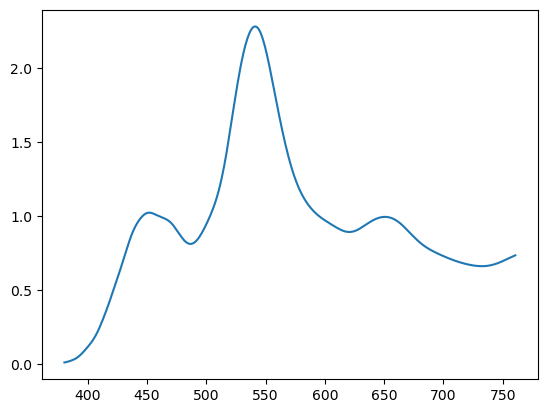

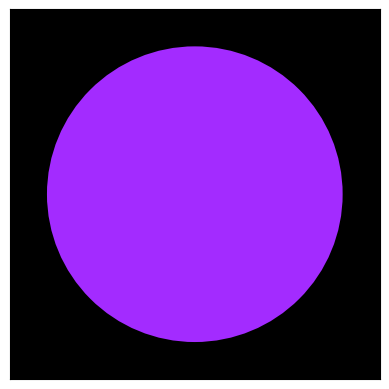

In [19]:
s = 0.08                                    # standard deviation parameter for gaussian broadening function
num_spec_points = 500                       # 
visible_ev = np.linspace(1.63, 3.26, 163)   # visible light energies


spectral_data = {'spec': [], 'w1': [], 'w2': [],
                 'w3': [], 'w4': [], 'w5': [],
                 'w6': [], 'w7': [], 'w8': [],
                 'w9': [], 'w10': [], 'f1': [],
                 'f2': [], 'f3': [], 'f4': [],
                 'f5': [], 'f6': [], 'f7': [],
                 'f8': [], 'f9': [], 'f10': []}


# a DataFrame to store the extracted excitation data
biliverdin_simulation_spectra = pd.DataFrame.from_dict(spectral_data)

for spec in biliverdin_species:
    
    os.chdir(f"{spec}")
    
    ds_idx = range(2, 5001) 
        
    spectral_data = {'spec': [], 'w1': [], 'w2': [], 'w3': [], 'w4': [],
                     'w5': [], 'w6': [], 'w7': [], 'w8': [], 'w9': [],
                     'w10': [], 'f1': [], 'f2': [], 'f3': [], 'f4': [],
                     'f5': [], 'f6': [], 'f7': [], 'f8': [], 'f9': [], 'f10': []}

    num_spectra_read = 0
    
    for idx in ds_idx:
        # try to open output files and in case ORCA did not finish with code 0 just pass    
        try:
            w1, w2, w3, w4, w5, w6, w7, w8, w9, w10, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10 = read_wavelengths_and_fosc(f'tddft_{idx+1}/calc.out')
            spectral_data['w1'].append(wb97xd_error(nm2ev(float(w1))))
            spectral_data['w2'].append(wb97xd_error(nm2ev(float(w2))))
            spectral_data['w3'].append(wb97xd_error(nm2ev(float(w3))))
            spectral_data['w4'].append(wb97xd_error(nm2ev(float(w4))))
            spectral_data['w5'].append(wb97xd_error(nm2ev(float(w5))))
            spectral_data['w6'].append(wb97xd_error(nm2ev(float(w6))))
            spectral_data['w7'].append(wb97xd_error(nm2ev(float(w7))))
            spectral_data['w8'].append(wb97xd_error(nm2ev(float(w8))))
            spectral_data['w9'].append(wb97xd_error(nm2ev(float(w9))))
            spectral_data['w10'].append(wb97xd_error(nm2ev(float(w10))))
            spectral_data['f1'].append(float(f1))
            spectral_data['f2'].append(float(f2))
            spectral_data['f3'].append(float(f3))
            spectral_data['f4'].append(float(f4))
            spectral_data['f5'].append(float(f5))
            spectral_data['f6'].append(float(f6))
            spectral_data['f7'].append(float(f7))
            spectral_data['f8'].append(float(f8))
            spectral_data['f9'].append(float(f9))
            spectral_data['f10'].append(float(f10))
            spectral_data['spec'].append(spec)
            num_spectra_read += 1
        except:
            pass

    spectral_data = pd.DataFrame.from_dict(spectral_data)
    biliverdin_simulation_spectra = pd.concat([biliverdin_simulation_spectra, spectral_data])
    spectral_data = {key: np.array(value) for key, value in spectral_data.items()}

    # place gaussians on excitaions and normalise a number of frames used
    sp = generate_spectra_from_single_excitations(spectral_data, s, num_spec_points)

    print(spec)
    # plot spectra and the corresponding colours
    fig, ax = plt.subplots()
    
    ax.plot(nm2ev(np.linspace(1.63, 3.26, num_spec_points)), sp)
    plt.show()
    
    colour = Spectrum(nm2ev(np.linspace(1.63, 3.26, num_spec_points)), sp, absorbance = True).rgb_to_hex()
    
    fig, ax = plt.subplots()
    
    circle = Circle(xy = (0, 0), radius = 0.4, fc = colour)
    ax.add_patch(circle)
 
    # Set the limits and background colour; remove the ticks
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('k')
    # Make sure our circles are circular!
    ax.set_aspect("equal")

    plt.show()
    #plt.savefig(f"colour_{spec}.png")
    
    
    os.chdir("..")

